# 📊 DỰ ÁN 1 — XÂY DỰNG MÔ HÌNH PHÂN LOẠI VÀ DỰ BÁO RỦI RO KHÁCH HÀNG VAY VỐN

**Notebook 01/07 — Data Understanding (Tìm hiểu dữ liệu)**

---

**🎯 Mục tiêu:** Khám phá tổng quan bộ dữ liệu **Home Credit Default Risk**: cấu trúc và quan hệ giữa các bảng, kích thước, kiểu dữ liệu, ý nghĩa các cột, tỷ lệ giá trị thiếu và phân bố biến mục tiêu `TARGET`.

**📥 Input:** `data/raw/*.csv` (application_train, application_test, bureau, bureau_balance, previous_application, installments_payments, credit_card_balance, POS_CASH_balance, HomeCredit_columns_description)

**📤 Output:** Không xuất file — kết quả là các hiểu biết ban đầu về dữ liệu, làm cơ sở cho các notebook sau.

**🔗 Pipeline:** *(bắt đầu)* → **01. Data Understanding** → nhánh Database: 02. PostgreSQL Pipeline; nhánh CSV: 03. Data Cleaning

## ⚙️ Hướng dẫn chuẩn bị trước khi chạy (Đọc kỹ)

Notebook này thực hiện tìm hiểu và khám phá tổng quan bộ dữ liệu thô. Để chạy được notebook mà không gặp lỗi, vui lòng thực hiện các bước chuẩn bị sau trên máy của bạn:

1. **Cài đặt thư viện:** Đảm bảo đã cài đặt đầy đủ các thư viện trong `requirements.txt` bằng lệnh:
   ```bash
   pip install -r requirements.txt
   ```
2. **Tải dữ liệu:** Tải bộ dữ liệu **Home Credit Default Risk** từ Kaggle và đặt đầy đủ 8 file CSV vào thư mục `data/raw/` (nếu chưa có thư mục này, hãy tạo nó ở thư mục gốc của dự án). Lưu ý viết hoa đúng tên file `POS_CASH_balance.csv`.
3. **Lưu ý cấu hình RAM:** Do các file dữ liệu thô khá lớn (tổng cộng ~2.5 GB, đặc biệt là `bureau_balance.csv` và `installments_payments.csv` có hàng chục triệu dòng), quá trình chạy cần tối thiểu **4GB - 8GB RAM trống**. Code đã sử dụng các hàm tối ưu hóa bộ nhớ (`del` và `gc.collect()`) để tránh lỗi tràn bộ nhớ (Out-Of-Memory).
4. **Tự động kiểm tra:** Notebook đã tích hợp sẵn đoạn kiểm tra tự động xem các file dữ liệu có tồn tại hay không ở ngay các ô code đầu tiên.

---

## 1. Mục tiêu & câu hỏi dẫn đường

Data Understanding là bước chuyển từ câu hỏi **"doanh nghiệp cần gì?"** sang câu hỏi **"dữ liệu nào có thể giúp giải quyết nhu cầu đó?"**. Vì vậy, notebook này không bắt đầu bằng việc làm sạch hay huấn luyện mô hình, mà bắt đầu bằng việc hiểu dữ liệu đang mô tả phần nào của quy trình cho vay.

Trong bộ Home Credit, dữ liệu có thể được nhìn như một **quy trình nghiệp vụ cho vay được ghi lại bằng bảng**: khách hàng nộp hồ sơ hiện tại, doanh nghiệp kiểm tra lịch sử tín dụng bên ngoài, xem các lần vay trước tại Home Credit, rồi theo dõi hành vi thanh toán, thẻ tín dụng và POS/cash loan theo thời gian.

Đến cuối notebook, mỗi thành viên cần trả lời được 5 ý lớn:

1. **Bộ dữ liệu gồm những bảng nào** — bảng hồ sơ vay hiện tại, các bảng lịch sử tín dụng, thanh toán, thẻ tín dụng và từ điển dữ liệu.
2. **Mỗi bảng đại diện cho phần nào trong nghiệp vụ cho vay** — bảng này đang kể phần nào của câu chuyện khách hàng vay vốn.
3. **Mỗi dòng trong bảng có ý nghĩa gì** — một hồ sơ vay, một khoản vay trước, một tháng lịch sử hay một kỳ thanh toán.
4. **Các bảng nối với nhau bằng khóa nào** — đặc biệt là `SK_ID_CURR`, `SK_ID_PREV` và `SK_ID_BUREAU`.
5. **Dữ liệu có vấn đề gì cần chú ý** — quy mô lớn, nhiều bảng, nhiều giá trị thiếu, mất cân bằng `TARGET`, giá trị bất thường và khác biệt cấp độ dữ liệu giữa các bảng.


## 2. Bối cảnh bài toán & nguồn dữ liệu

### 2.1. Bối cảnh nghiệp vụ & nguồn dữ liệu

**Home Credit Group** là tập đoàn tài chính tiêu dùng quốc tế, tập trung phục vụ nhóm khách hàng **thiếu hồ sơ tín dụng ngân hàng** (*unbanked / underbanked*) — những người có nhu cầu vay thật nhưng chưa từng giao dịch với ngân hàng truyền thống nên không có điểm tín dụng để tra cứu.

Nhóm khách hàng này đặt tổ chức cho vay vào một thế lưỡng nan:

- **Từ chối toàn bộ** vì thiếu hồ sơ → mất thị phần, đồng thời đẩy khách sang các kênh tín dụng phi chính thức với lãi suất cao hơn.
- **Cho vay đại trà** → tỷ lệ mất vốn tăng, hoạt động kinh doanh không bền vững.

Lối ra là **lượng hóa rủi ro dựa trên dữ liệu thay thế**: nếu khách chưa có điểm tín dụng ngân hàng, hãy suy ra khả năng trả nợ từ những dấu vết tài chính khác — lịch sử vay tại tổ chức tín dụng khác, hành vi trả góp các khoản vay trước, mức sử dụng thẻ tín dụng. Đây chính là lý do bộ dữ liệu được công bố, và cũng giải thích vì sao nó có tới **6 bảng lịch sử** bên cạnh bảng hồ sơ chính.

**Nguồn dữ liệu:** cuộc thi *Home Credit Default Risk* do Home Credit Group tổ chức trên Kaggle năm 2018 — <https://www.kaggle.com/competitions/home-credit-default-risk/data> (đường dẫn theo đề bài). Bộ dữ liệu gồm **8 file CSV (~2,5 GB)** kèm file từ điển `HomeCredit_columns_description.csv` mô tả 219 cột.

### 2.2. Phát biểu bài toán dưới dạng học máy

| Thành phần | Nội dung |
|---|---|
| **Đầu vào (features)** | Hồ sơ khách tại thời điểm nộp đơn (`application_train`, 122 cột) **cộng với** các đặc trưng tổng hợp từ 6 bảng lịch sử |
| **Đầu ra (label)** | `TARGET` ∈ {0, 1} — xác suất khách gặp khó khăn trả nợ |
| **Loại bài toán** | **Phân loại nhị phân, có giám sát** (*supervised binary classification*) |
| **Chỉ số đánh giá** | **ROC-AUC** — cũng là chỉ số chấm điểm chính thức của cuộc thi gốc |

**Vì sao là phân loại chứ không phải bài toán khác:**

- **Không phải hồi quy (regression):** thứ cần dự đoán là một **nhãn rời rạc** (có / không gặp khó khăn trả nợ), không phải đại lượng liên tục như số tiền hay số ngày. Mô hình vẫn xuất ra *xác suất* liên tục, nhưng xác suất ở đây là **mức độ tin cậy của nhãn**, không phải giá trị cần dự báo.
- **Không phải phân cụm (clustering):** dữ liệu **đã có sẵn nhãn đúng** (`TARGET`) cho toàn bộ 307.511 khách. Có nhãn để học nghĩa là bài toán **có giám sát**; phân cụm chỉ dùng khi không có nhãn và ta muốn tự tìm ra các nhóm ẩn.

**Hai chỉ số cần phân biệt rõ:**

- **Accuracy (độ chính xác)** = số lần đoán đúng chia cho tổng số lần đoán. Trực quan, nhưng **không dùng được cho bài toán này**: do dữ liệu lệch ~8/92 (xác nhận ở **mục 5.2**), một mô hình luôn trả lời "an toàn" cho mọi khách vẫn đạt accuracy ~92% mà không phát hiện được một khách rủi ro nào. Với dữ liệu lệch, accuracy phản ánh **tỷ lệ của nhóm đông**, không phản ánh năng lực mô hình.
- **ROC-AUC** đo khả năng **xếp hạng** thay vì đếm số lần đoán đúng. Cách hiểu gọn nhất: *bốc ngẫu nhiên một khách vỡ nợ thật và một khách an toàn thật — AUC chính là **xác suất mô hình chấm điểm rủi ro cho người vỡ nợ cao hơn người an toàn**.* Thang đo: **0,5** = đoán bừa (ngang tung đồng xu), **1,0** = hoàn hảo. Vì phép đo luôn so **một cặp gồm một người mỗi nhóm**, tỷ lệ lệch 8/92 không tham gia vào kết quả — nhờ đó AUC **miễn nhiễm với mất cân bằng lớp**.

> 📌 **Đầy đủ hơn ở Notebook 06** (mục 4 và 5.1): đường cong ROC, cách chọn **ngưỡng quyết định**, và ý nghĩa kinh doanh của phép đánh đổi. Ở đó có một phép thử đối chứng đáng chú ý — mô hình `Dummy` (luôn trả lời "không vỡ nợ") đạt accuracy **91,93%**, sát nút mô hình tốt nhất (**92,01%**), nhưng AUC chỉ **0,5000** so với **0,7792**. Đó là bằng chứng số học trực tiếp cho cảnh báo ở trên.


## 3. Chuẩn bị môi trường

Thiết lập thư viện, cấu hình hiển thị và đường dẫn tới dữ liệu thô.

**Vai trò của từng thư viện trong notebook này:**

| Thư viện | Vai trò |
|---|---|
| `pandas` | Đọc CSV và thao tác dữ liệu dạng bảng (DataFrame) — công cụ chính của toàn bộ notebook |
| `numpy` | Nền tảng tính toán số học mà pandas dựa lên; ở notebook này chủ yếu dùng gián tiếp |
| `matplotlib` / `seaborn` | Vẽ biểu đồ. `seaborn` là lớp bọc trên `matplotlib`, cho cú pháp ngắn gọn hơn với biểu đồ thống kê |
| `gc` (garbage collector) | Thu hồi bộ nhớ ngay sau khi giải phóng một bảng lớn — cần thiết vì dữ liệu thô tổng ~2,5 GB |
| `pathlib.Path` | Biểu diễn đường dẫn độc lập hệ điều hành, giúp notebook chạy được trên cả Windows và Linux |

**Về cấu hình hiển thị:** đặt `display.max_columns = 120` để pandas không rút gọn cột khi in bảng 122 cột; `display.float_format` để số thực hiển thị dạng phân tách hàng nghìn thay vì ký hiệu khoa học (`1.68e+05`).

**Về đường dẫn `DATA_RAW`:** notebook dò lần lượt `data/raw` rồi `../data/raw` và lấy đường dẫn nào tồn tại. Cách này giúp notebook chạy đúng dù được mở từ thư mục `notebooks/` hay từ thư mục gốc của repo — một nguồn lỗi thường gặp khi nhiều máy có cách mở notebook khác nhau.

Các cell trong mục này là thiết lập kỹ thuật thuần túy nên không kèm nhận xét.


In [1]:
# Thư viện xử lý dữ liệu & trực quan hóa
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Cấu hình hiển thị
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.3 | numpy 2.4.6


In [2]:
# Đường dẫn tới dữ liệu thô (chạy được dù notebook mở từ notebooks/ hay từ gốc repo)
DATA_RAW = next((p for p in [Path("data/raw"), Path("../data/raw")] if p.exists()), Path("../data/raw"))

# Danh sách bảng dữ liệu Home Credit (tên file -> mô tả ngắn tiếng Việt)
TABLES = {
    "application_train.csv":      "Đơn vay chính (có cột TARGET) — bảng trung tâm để train",
    "application_test.csv":       "Đơn vay chính dùng để dự đoán (không có TARGET)",
    "bureau.csv":                 "Khoản vay tại tổ chức tín dụng khác (từ Credit Bureau)",
    "bureau_balance.csv":         "Số dư hàng tháng của các khoản vay trong bureau",
    "previous_application.csv":   "Các đơn vay trước đây tại Home Credit",
    "installments_payments.csv":  "Lịch sử trả góp của các khoản vay trước",
    "credit_card_balance.csv":    "Số dư thẻ tín dụng hàng tháng",
    "POS_CASH_balance.csv":       "Số dư khoản vay POS/tiền mặt hàng tháng",
}

print("Thư mục dữ liệu thô:", DATA_RAW.resolve())
for f in TABLES:
    p = DATA_RAW / f
    size_mb = p.stat().st_size / 1024**2 if p.exists() else 0
    print(f"  {'OK ' if p.exists() else 'MISSING'} {f:<28} {size_mb:8.1f} MB")

# Kiểm tra xem có thiếu file dữ liệu thô nào không để cảnh báo dừng sớm
missing_files = [f for f in TABLES if not (DATA_RAW / f).exists()]
if missing_files:
    raise FileNotFoundError(
        f"❌ LỖI: Thiếu {len(missing_files)} file dữ liệu thô trong thư mục '{DATA_RAW.resolve()}':\n"
        f"   {missing_files}\n"
        f"Vui lòng tải bộ dữ liệu 'Home Credit Default Risk' từ Kaggle và đặt vào đúng thư mục!"
    )


Thư mục dữ liệu thô: D:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\data\raw
  OK  application_train.csv           158.4 MB
  OK  application_test.csv             25.3 MB
  OK  bureau.csv                      162.1 MB
  OK  bureau_balance.csv              358.2 MB
  OK  previous_application.csv        386.2 MB
  OK  installments_payments.csv       689.6 MB
  OK  credit_card_balance.csv         404.9 MB
  OK  POS_CASH_balance.csv            374.5 MB


## 4. Bản đồ dữ liệu: các bảng và quy mô

Quét lần lượt từng bảng để lấy: số dòng, số cột, dung lượng khi nạp vào RAM, tổng số ô thiếu và tỷ lệ thiếu.

**Vì sao nạp rồi giải phóng ngay từng bảng:** tổng dữ liệu thô ~2,5 GB trên đĩa, và khi nạp vào RAM còn phình to hơn (pandas phải cấp phát thêm cho chỉ mục và chuỗi ký tự). Nếu giữ cả 8 bảng cùng lúc trong bộ nhớ, máy có RAM vừa phải sẽ tràn bộ nhớ (Out-Of-Memory). Vì mục này chỉ cần *thống kê tổng quan* chứ không cần dữ liệu, hàm `profile_table` nạp một bảng → tính xong các chỉ số → `del` và `gc.collect()` để trả bộ nhớ về hệ điều hành trước khi sang bảng kế tiếp. Nhờ vậy đỉnh RAM chỉ bằng bảng lớn nhất, không phải tổng 8 bảng.

**Các chỉ số được đo và ý nghĩa:**

| Chỉ số | Ý nghĩa |
|---|---|
| Số dòng / Số cột | Kích thước bảng. Chênh lệch số dòng giữa các bảng cho biết cấp độ chi tiết (một dòng = một khách hàng, một khoản vay, hay một tháng) |
| Cột số / Cột chữ | Cột chữ là biến phân loại, sẽ phải mã hóa thành số trước khi đưa vào mô hình (notebook 05) |
| RAM (MB) | Dung lượng thật khi bảng nằm trong bộ nhớ — căn cứ để ước lượng máy cần bao nhiêu RAM |
| Ô thiếu (%) | Tỷ lệ ô trống trên tổng số ô. Đây là căn cứ đầu tiên để lên kế hoạch làm sạch ở notebook 03 |


In [3]:
def profile_table(path):
    """Nạp 1 bảng, trả về thống kê tổng quan rồi giải phóng bộ nhớ."""
    df = pd.read_csv(path)
    n_rows, n_cols = df.shape                       # .shape trả về bộ đôi (số dòng, số cột)

    # memory_usage(deep=True): đo dung lượng thật của bảng trong RAM.
    # Tham số deep=True bắt buộc ở đây — nếu thiếu, pandas chỉ đếm con trỏ của
    # cột chữ chứ không đếm nội dung chuỗi, làm kết quả nhỏ hơn thực tế rất nhiều.
    mem_mb = df.memory_usage(deep=True).sum() / 1024**2   # 1024**2 byte = 1 MB

    # Tỷ lệ thiếu = (số ô trống) / (tổng số ô của bảng).
    # df.isna() cho bảng True/False cùng kích thước; .sum() lần 1 cộng theo từng
    # cột, .sum() lần 2 cộng nốt thành một số duy nhất cho cả bảng.
    total_cells = n_rows * n_cols
    missing_cells = int(df.isna().sum().sum())
    missing_pct = missing_cells / total_cells * 100 if total_cells else 0  # tránh chia cho 0 nếu bảng rỗng

    # select_dtypes lọc cột theo kiểu dữ liệu; [1] lấy số cột từ bộ đôi .shape
    n_numeric = df.select_dtypes(include="number").shape[1]
    n_object = df.select_dtypes(include="object").shape[1]

    # Trả bộ nhớ về hệ điều hành TRƯỚC khi nạp bảng kế tiếp (xem giải thích ở trên).
    del df
    gc.collect()

    return {
        "Số dòng": n_rows,
        "Số cột": n_cols,
        "Cột số": n_numeric,
        "Cột chữ": n_object,
        "RAM (MB)": round(mem_mb, 1),
        "Ô thiếu (%)": round(missing_pct, 2),
    }


# Quét lần lượt 8 bảng, gom kết quả vào dict: {tên file: {chỉ số: giá trị}}
rows = {}
for fname in TABLES:
    p = DATA_RAW / fname
    if p.exists():
        rows[fname] = profile_table(p)
        print("Đã quét:", fname)

# DataFrame(rows) đặt mỗi bảng thành một CỘT; .T (transpose) xoay lại để mỗi bảng là một DÒNG
overview = pd.DataFrame(rows).T
overview.index.name = "Bảng"

# Hiển thị gọn: các cột đếm là số nguyên; RAM giữ 1 chữ số; tỷ lệ thiếu giữ 2 chữ số.
overview_display = overview.style.format({
    "Số dòng": "{:,.0f}",
    "Số cột": "{:,.0f}",
    "Cột số": "{:,.0f}",
    "Cột chữ": "{:,.0f}",
    "RAM (MB)": "{:,.1f}",
    "Ô thiếu (%)": "{:,.2f}",
})
overview_display

Đã quét: application_train.csv


Đã quét: application_test.csv


Đã quét: bureau.csv


Đã quét: bureau_balance.csv


Đã quét: previous_application.csv


Đã quét: installments_payments.csv


Đã quét: credit_card_balance.csv


Đã quét: POS_CASH_balance.csv


,Số dòng,Số cột,Cột số,Cột chữ,RAM (MB),Ô thiếu (%)
Bảng,,,,,,
application_train.csv,"307,511",122,106,16,325.2,24.40
application_test.csv,"48,744",121,105,16,51.2,23.81
bureau.csv,"1,716,428",17,14,3,271.5,13.50
bureau_balance.csv,"27,299,925",3,2,1,650.9,0.00
previous_application.csv,"1,670,214",37,21,16,671.8,17.98
installments_payments.csv,"13,605,401",8,8,0,830.4,0.01
credit_card_balance.csv,"3,840,312",23,22,1,696.2,6.65
POS_CASH_balance.csv,"10,001,358",8,7,1,669.9,0.07


**Nhận xét:**

- Bộ dữ liệu gồm 8 bảng với quy mô rất khác nhau: `application_train/test` là bảng trung tâm (mỗi dòng = 1 đơn vay, khóa `SK_ID_CURR`), còn các bảng phụ như `bureau_balance`, `installments_payments`, `credit_card_balance`, `POS_CASH_balance` có **hàng triệu → hàng chục triệu dòng** vì lưu lịch sử theo tháng/giao dịch.
- Nhiều bảng có tỷ lệ ô thiếu đáng kể (đặc biệt `application_train` do nhóm cột mô tả nhà ở). Đây là căn cứ để lên kế hoạch xử lý thiếu ở notebook 03 (Data Cleaning).
- Quan hệ nhiều-một giữa bảng phụ và bảng chính cho thấy muốn dùng thông tin lịch sử phải **tổng hợp (aggregate)** về mức `SK_ID_CURR` — sẽ làm ở notebook 05 (Feature Engineering).


## 5. Bảng trung tâm — `application_train`

Đây là bảng dùng để huấn luyện mô hình. Ta nạp riêng và phân tích sâu: kiểu dữ liệu, biến mục tiêu, giá trị thiếu và thống kê mô tả.


In [4]:
app = pd.read_csv(DATA_RAW / "application_train.csv")
print("Kích thước application_train:", app.shape)
app.head()

Kích thước application_train: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,...,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,"202,500.0000","406,597.5000","24,700.5000","351,000.0000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,"-3,648.0000",-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,...,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0000,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,"-1,134.0000",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,"270,000.0000","1,293,502.5000","35,698.5000","1,129,500.0000",Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,"-1,186.0000",-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,...,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0000,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.0000","135,000.0000","6,750.0000","135,000.0000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,"-4,260.0000",-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.5559,0.7296,NaN,NaN

### 5.1. Kích thước & kiểu dữ liệu

*Kiểu dữ liệu (dtype)* quyết định cột được xử lý ra sao ở các bước sau. Ba nhóm gặp trong bảng này:

- `int64` — số nguyên (số con, số ngày).
- `float64` — số thực; **mọi cột có ô thiếu đều buộc phải mang kiểu này**, vì `NaN` chỉ tồn tại ở dạng số thực. Đây là lý do nhiều cột đếm vẫn hiện `float64`.
- `str` — chuỗi ký tự, tức **biến phân loại** (giới tính, trình độ học vấn, loại hợp đồng…). Mô hình học máy chỉ nhận số, nên nhóm này phải được **mã hóa (encoding)** ở notebook 05.

📌 **Lưu ý phiên bản:** từ pandas 3.0, cột chữ được báo là `str` thay vì `object` như các phiên bản trước, nên bảng đếm dtype bên dưới hiện `str 16`. Truy vấn `select_dtypes(include="object")` vẫn bắt đúng 16 cột này để giữ tương thích ngược. Cần lưu ý điểm này khi đối chiếu với tài liệu hoặc notebook viết cho pandas 2.x — đây từng là nguồn lỗi thật của dự án (xem `README.md`, mục các bẫy đã biết).


In [5]:
print("Số dòng: {:,} | Số cột: {}".format(*app.shape))
print("\nPhân bố kiểu dữ liệu các cột:")
print(app.dtypes.value_counts())

print("\nMột số cột dạng chữ (object) tiêu biểu:")
print(list(app.select_dtypes(include="object").columns)[:15])

Số dòng: 307,511 | Số cột: 122

Phân bố kiểu dữ liệu các cột:
float64    65
int64      41
str        16
Name: count, dtype: int64

Một số cột dạng chữ (object) tiêu biểu:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE']


**Nhận xét:**

- `application_train` có 307.511 dòng và 122 cột — mỗi dòng là một đơn vay của một khách hàng.
- Đa số cột là kiểu số (`float64`/`int64`); nhóm cột `object` là các biến phân loại như giới tính, loại hợp đồng, trình độ học vấn, tình trạng hôn nhân, loại hình tổ chức... sẽ cần mã hóa (encoding) trước khi đưa vào mô hình.


### 5.2. Biến mục tiêu `TARGET`

`TARGET` là cột mà mô hình phải học để dự đoán. Theo định nghĩa gốc trong `HomeCredit_columns_description.csv`:

> *Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)*

Nghĩa là `TARGET = 1` khi khách **trễ hạn quá X ngày ở ít nhất một trong Y kỳ trả góp đầu tiên**; `TARGET = 0` cho mọi trường hợp còn lại. Cần lưu ý sắc thái này khi diễn giải kết quả: nhãn 1 phản ánh **khó khăn trả nợ giai đoạn đầu**, không phải "khách đã phá sản" — Home Credit cố ý chọn tín hiệu sớm để có thể can thiệp kịp thời.

Chỉ có hai giá trị 0/1 nên đây là bài toán **phân loại nhị phân (binary classification)**.

**Về đoạn code bên dưới:** `value_counts()` đếm số dòng theo từng giá trị của cột; thêm `normalize=True` thì trả về **tỷ lệ** thay vì số đếm (nhân 100 để ra phần trăm). `sort_index()` sắp theo giá trị 0 → 1 để thứ tự nhãn luôn ổn định. Hai biểu đồ bổ sung cho nhau: biểu đồ cột cho thấy **số lượng tuyệt đối**, biểu đồ tròn cho thấy **tỷ lệ tương đối** — mức mất cân bằng chỉ lộ rõ ở biểu đồ tròn.


,Số lượng,Tỷ lệ (%)
0 — Trả nợ tốt,282686,91.9300
1 — Khó khăn trả nợ (default),24825,8.0700


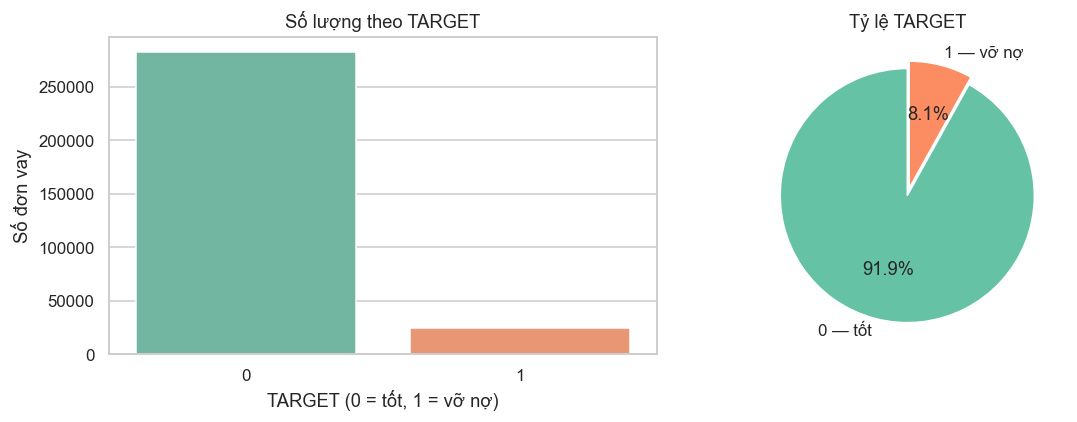

In [6]:
target_counts = app["TARGET"].value_counts().sort_index()
target_pct = app["TARGET"].value_counts(normalize=True).sort_index() * 100
target_df = pd.DataFrame({"Số lượng": target_counts, "Tỷ lệ (%)": target_pct.round(2)})
target_df.index = ["0 — Trả nợ tốt", "1 — Khó khăn trả nợ (default)"]
display(target_df)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="TARGET", data=app, ax=ax[0], palette="Set2")
ax[0].set_title("Số lượng theo TARGET")
ax[0].set_xlabel("TARGET (0 = tốt, 1 = vỡ nợ)")
ax[0].set_ylabel("Số đơn vay")
ax[1].pie(target_counts, labels=["0 — tốt", "1 — vỡ nợ"], autopct="%1.1f%%",
          colors=sns.color_palette("Set2"), startangle=90, explode=(0, 0.06))
ax[1].set_title("Tỷ lệ TARGET")
plt.tight_layout()
plt.show()

**Nhận xét:**

- Biến mục tiêu **mất cân bằng nghiêm trọng**: chỉ khoảng **8%** khách hàng thuộc nhóm khó khăn trả nợ (`TARGET = 1`), còn lại ~92% trả nợ tốt.
- **Hệ quả 1 — accuracy là thước đo gây hiểu nhầm.** Một mô hình "rỗng" luôn trả lời `0` cho mọi khách sẽ đạt accuracy ~92% mà **không phát hiện được một khách rủi ro nào** — vô dụng về mặt nghiệp vụ nhưng nhìn con số lại tưởng tốt. Vì vậy notebook 06 phải đánh giá bằng **ROC-AUC, Precision/Recall, F1** thay cho accuracy.
- **Hệ quả 2 — ngưỡng quyết định mặc định không dùng được.** Các thư viện phân loại mặc định cắt ở xác suất 0,5; với dữ liệu lệch 8/92, rất ít khách vượt nổi ngưỡng đó nên mô hình gần như luôn trả lời "an toàn". Ngưỡng phải được chọn lại dựa trên dữ liệu (notebook 06) thay vì giữ giá trị mặc định.
- **Hệ quả 3 — hai loại sai lầm có giá khác nhau.** Bỏ sót một khách vỡ nợ (cho vay rồi mất vốn) tốn kém hơn nhiều so với từ chối nhầm một khách tốt (mất phần lãi). Đây là lý do bài toán ưu tiên **Recall của nhóm `TARGET = 1`**, và cũng là căn cứ nghiệp vụ để chấp nhận hạ ngưỡng quyết định.


### 5.3. Giá trị thiếu (missing values)

Ô thiếu (`NaN` — *Not a Number*) là ô không có dữ liệu. Đa số thuật toán học máy không chấp nhận `NaN`, nên mọi ô thiếu đều phải được xử lý trước khi huấn luyện: hoặc **điền khuyết (imputation)** bằng một giá trị suy ra từ thống kê, hoặc **loại bỏ cột** nếu thiếu quá nhiều đến mức không còn thông tin để suy.

**Về đoạn code bên dưới:** `app.isna()` trả về một bảng True/False cùng kích thước (True = ô trống); `.sum()` cộng theo từng cột, cho ra số ô thiếu của mỗi cột. Sau đó lọc `miss > 0` để chỉ giữ các cột thật sự có thiếu, và chia cho `len(app)` để đổi số đếm thành tỷ lệ phần trăm — tỷ lệ mới là thứ so sánh được giữa các cột.

⚠️ **Lưu ý phương pháp:** tỷ lệ thiếu cao **không** đủ để kết luận nên bỏ một cột. Quyết định giữ hay bỏ phải cân nhắc thêm **mức độ liên quan tới `TARGET`**; một cột thiếu nhiều nhưng có sức phân biệt mạnh vẫn đáng giữ và điền khuyết. Nhóm `EXT_SOURCE_*` bên dưới là ví dụ điển hình.


Số cột có giá trị thiếu: 67 / 122

Top 20 cột thiếu nhiều nhất:


,Số ô thiếu,Tỷ lệ thiếu (%)
COMMONAREA_MEDI,214865,69.8700
COMMONAREA_MODE,214865,69.8700
COMMONAREA_AVG,214865,69.8700
NONLIVINGAPARTMENTS_MODE,213514,69.4300
NONLIVINGAPARTMENTS_MEDI,213514,69.4300
NONLIVINGAPARTMENTS_AVG,213514,69.4300
FONDKAPREMONT_MODE,210295,68.3900
LIVINGAPARTMENTS_AVG,210199,68.3500
LIVINGAPARTMENTS_MEDI,210199,68.3500
LIVINGAPARTMENTS_MODE,210199,68.3500


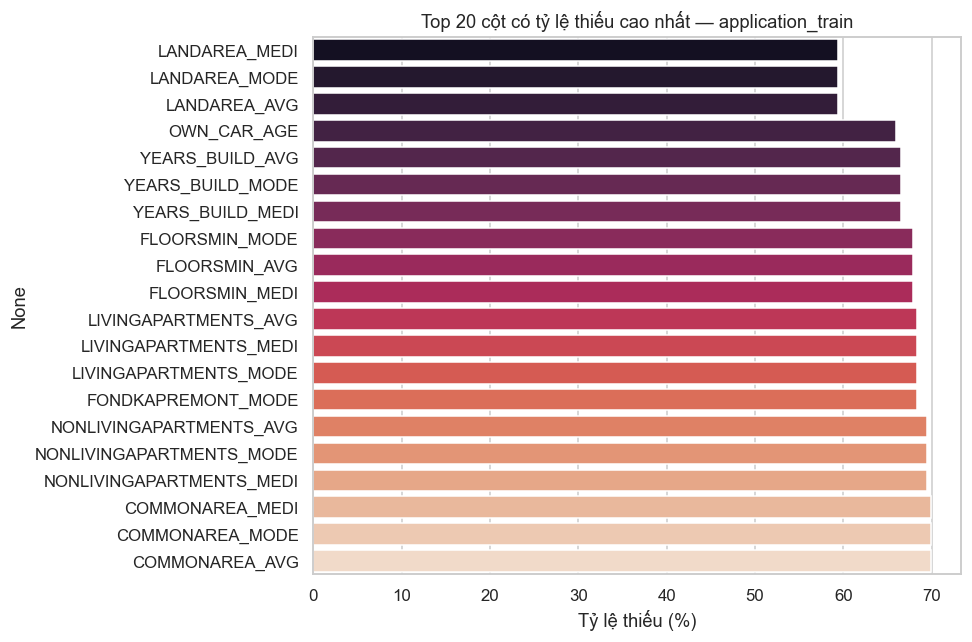

In [7]:
miss = app.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(app) * 100).round(2)
miss_table = pd.DataFrame({"Số ô thiếu": miss, "Tỷ lệ thiếu (%)": miss_pct})

print(f"Số cột có giá trị thiếu: {len(miss)} / {app.shape[1]}")
print("\nTop 20 cột thiếu nhiều nhất:")
display(miss_table.head(20))

plt.figure(figsize=(9, 6))
top = miss_pct.head(20).sort_values()
sns.barplot(x=top.values, y=top.index, palette="rocket")
plt.xlabel("Tỷ lệ thiếu (%)")
plt.title("Top 20 cột có tỷ lệ thiếu cao nhất — application_train")
plt.tight_layout()
plt.show()

**Nhận xét:**

- Có tới ~67 cột chứa giá trị thiếu. Nhóm thiếu nhiều nhất (>50%) chủ yếu là các đặc trưng mô tả **nhà ở / căn hộ** (`*_AVG`, `*_MODE`, `*_MEDI`) và `OWN_CAR_AGE`.
- Nhóm `EXT_SOURCE_1/2/3` (điểm tín dụng từ nguồn ngoài) thiếu vừa phải nhưng thường **rất quan trọng** cho dự đoán — cần chiến lược điền khuyết cẩn thận thay vì loại bỏ.
- Đây là đầu vào trực tiếp cho notebook 03 (Data Cleaning): cột thiếu quá nhiều có thể loại bỏ, cột quan trọng thì điền khuyết bằng thống kê hoặc mô hình.


### 5.4. Thống kê mô tả biến số & biến phân loại

`describe()` tóm tắt mỗi cột số bằng 8 chỉ số: `count` (số ô có dữ liệu), `mean` (trung bình), `std` (độ lệch chuẩn — mức phân tán quanh trung bình), `min`/`max`, và ba **phân vị** `25%` / `50%` / `75%`. Phân vị 50% chính là **trung vị (median)** — giá trị nằm chính giữa khi sắp xếp dữ liệu.

**Vì sao đọc cả trung bình lẫn trung vị:** trung bình bị vài giá trị cực lớn kéo lệch, trung vị thì không. Khi hai con số này cách xa nhau, đó là dấu hiệu phân phối **lệch (skewed)** và có ngoại lệ (outlier) — thông tin quan trọng cho bước làm sạch.

**Quy ước đọc các cột `DAYS_*`:** những cột này đếm ngược từ ngày nộp đơn nên **mang giá trị âm**. Ví dụ `DAYS_BIRTH = -16000` nghĩa là khách sinh ra 16.000 ngày *trước* ngày nộp đơn (≈ 43,8 tuổi). Đây là quy ước của Home Credit, không phải lỗi dữ liệu; cell bên dưới quy đổi sang năm (`-DAYS_BIRTH / 365`) cho dễ đối chiếu với thực tế.

**Về `mode()` ở cell biến phân loại:** *mode* là **giá trị xuất hiện nhiều nhất** trong cột. Với biến phân loại, mode đóng vai trò tương tự trung vị của biến số — nó cho biết nhóm phổ biến nhất, và cũng là giá trị thường được dùng để điền khuyết.


In [8]:
# Thống kê mô tả một số biến số quan trọng
cols_num = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE",
            "DAYS_BIRTH", "DAYS_EMPLOYED", "CNT_CHILDREN", "CNT_FAM_MEMBERS",
            "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
app[cols_num].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,"307,511.0000","168,797.9193","237,123.1463","25,650.0000","112,500.0000","147,150.0000","202,500.0000","117,000,000.0000"
AMT_CREDIT,"307,511.0000","599,025.9997","402,490.7770","45,000.0000","270,000.0000","513,531.0000","808,650.0000","4,050,000.0000"
AMT_ANNUITY,"307,499.0000","27,108.5739","14,493.7373","1,615.5000","16,524.0000","24,903.0000","34,596.0000","258,025.5000"
AMT_GOODS_PRICE,"307,233.0000","538,396.2074","369,446.4605","40,500.0000","238,500.0000","450,000.0000","679,500.0000","4,050,000.0000"
DAYS_BIRTH,"307,511.0000","-16,036.9951","4,363.9886","-25,229.0000","-19,682.0000","-15,750.0000","-12,413.0000","-7,489.0000"
DAYS_EMPLOYED,"307,511.0000","63,815.0459","141,275.7665","-17,912.0000","-2,760.0000","-1,213.0000",-289.0000,"365,243.0000"
CNT_CHILDREN,"307,511.0000",0.4171,0.7221,0.0000,0.0000,0.0000,1.0000,19.0000
CNT_FAM_MEMBERS,"307,509.0000",2.1527,0.9107,1.0000,2.0000,2.0000,3.0000,20.0000
EXT_SOURCE_1,"134,133.0000",0.5021,0.2111,0.0146,0.3340,0.5060,0.6751,0.9627
EXT_SOURCE_2,"306,851.0000",0.5144,0.1911,0.0000,0.3925,0.5660,0.6636,0.8550


In [9]:
# Quy đổi vài cột thời gian (đơn vị ngày âm tính từ ngày nộp đơn) sang năm cho dễ đọc
tuoi = (-app["DAYS_BIRTH"] / 365).describe()[["min", "mean", "max"]]
print("Tuổi khách hàng (năm): min={:.1f}, trung bình={:.1f}, max={:.1f}".format(*tuoi))

emp = app["DAYS_EMPLOYED"]
print("\nDAYS_EMPLOYED có giá trị bất thường lớn nhất:", emp.max(),
      "-> xuất hiện", (emp == emp.max()).sum(), "lần (mã hóa 'không đi làm').")

Tuổi khách hàng (năm): min=20.5, trung bình=43.9, max=69.1

DAYS_EMPLOYED có giá trị bất thường lớn nhất: 365243 -> xuất hiện 55374 lần (mã hóa 'không đi làm').


In [10]:
# Biến phân loại: số giá trị khác nhau, giá trị phổ biến nhất và số ô thiếu của từng cột.
obj_cols = app.select_dtypes(include="object").columns   # tên các cột kiểu chữ

rows_cat = []
for col in obj_cols:
    # nunique() đếm số giá trị KHÁC NHAU trong cột (tự động bỏ qua ô thiếu).
    # Con số này quyết định chi phí One-Hot Encoding ở notebook 05: mỗi giá trị
    # khác nhau sẽ sinh thêm một cột mới.
    so_gia_tri_khac_nhau = app[col].nunique()

    so_o_thieu = app[col].isna().sum()

    # mode() trả về một Series (có thể chứa nhiều giá trị nếu đồng hạng) nên phải
    # lấy phần tử đầu bằng [0]. Cột toàn ô thiếu sẽ cho Series rỗng -> kiểm tra
    # notna().any() trước để tránh lỗi IndexError.
    if app[col].notna().any():
        gia_tri_pho_bien_nhat = app[col].mode(dropna=True)[0]
    else:
        gia_tri_pho_bien_nhat = None

    rows_cat.append({
        "Cột": col,
        "Số giá trị khác nhau": so_gia_tri_khac_nhau,
        "Giá trị phổ biến nhất": gia_tri_pho_bien_nhat,
        "Số ô thiếu": so_o_thieu,
    })

# Gom danh sách các dòng thành bảng, lấy tên cột làm chỉ mục, sắp xếp giảm dần
# theo số giá trị khác nhau để các cột "nặng" khi One-Hot hiện lên đầu.
cat_summary = (
    pd.DataFrame(rows_cat)
    .set_index("Cột")
    .sort_values("Số giá trị khác nhau", ascending=False)
)
cat_summary

,Số giá trị khác nhau,Giá trị phổ biến nhất,Số ô thiếu
Cột,,,
ORGANIZATION_TYPE,58,Business Entity Type 3,0
OCCUPATION_TYPE,18,Laborers,96391
NAME_INCOME_TYPE,8,Working,0
NAME_TYPE_SUITE,7,Unaccompanied,1292
WALLSMATERIAL_MODE,7,Panel,156341
WEEKDAY_APPR_PROCESS_START,7,TUESDAY,0
NAME_FAMILY_STATUS,6,Married,0
NAME_HOUSING_TYPE,6,House / apartment,0
NAME_EDUCATION_TYPE,5,Secondary / secondary special,0


**Nhận xét:**

- Các biến tiền tệ (`AMT_INCOME_TOTAL`, `AMT_CREDIT`...) **lệch phải mạnh** (max lớn hơn trung vị rất nhiều) → có ngoại lệ, nên cân nhắc biến đổi log hoặc cắt ngưỡng khi mô hình hóa.
- `DAYS_BIRTH`/`DAYS_EMPLOYED` là **số ngày âm** tính từ ngày nộp đơn. Riêng `DAYS_EMPLOYED` có giá trị bất thường `365243` (~1000 năm) dùng để mã hóa nhóm **không đi làm** (hưu trí/thất nghiệp) — cần thay bằng NaN ở bước làm sạch.
- Biến phân loại phần lớn có số mức nhỏ (dễ one-hot); riêng `ORGANIZATION_TYPE`, `OCCUPATION_TYPE` nhiều mức và có ô thiếu → cần xử lý riêng.


## 6. Các bảng phụ & quan hệ khóa

Bảng `application_train` chỉ chứa thông tin **tại thời điểm nộp đơn**. Toàn bộ **lịch sử tín dụng** của khách nằm rải ở 6 bảng phụ, và chúng được nối với nhau qua các cột **khóa**.

**Khóa chính và khóa ngoại.** Một *khóa chính (primary key)* là cột định danh duy nhất mỗi dòng của bảng — tương tự mã số sinh viên trong bảng danh sách sinh viên. Một *khóa ngoại (foreign key)* là cột ở bảng khác trỏ ngược về khóa chính đó — tương tự cột mã số sinh viên trong bảng điểm. Một sinh viên có **một** dòng ở bảng danh sách nhưng **nhiều** dòng ở bảng điểm (mỗi môn một dòng); đó chính là quan hệ **một-nhiều (1-n)**. Bộ Home Credit vận hành đúng theo nguyên tắc này, chỉ khác ở chỗ quan hệ 1-n còn **lồng nhau nhiều tầng**.

**Ba khóa của bộ dữ liệu:**

| Khóa | Định danh cho | Nối những bảng nào |
|---|---|---|
| `SK_ID_CURR` | Đơn vay **hiện tại** đang xét | `application_*` ↔ `bureau`, `previous_application`, và cả 3 bảng số dư |
| `SK_ID_BUREAU` | Một khoản vay tại **tổ chức tín dụng khác** | `bureau` ↔ `bureau_balance` |
| `SK_ID_PREV` | Một khoản vay **trước đây tại Home Credit** | `previous_application` ↔ `installments_payments`, `credit_card_balance`, `POS_CASH_balance` |

**Sơ đồ quan hệ giữa 8 bảng** (số dòng đo trên dữ liệu thật):

![ERD tổng quan bộ dữ liệu Home Credit](../reports/images/home_credit_erd.png)

Sơ đồ trên cho thấy `application_train/test` là bảng trung tâm ở mức hồ sơ vay hiện tại. Các bảng lịch sử nối về khách hàng qua `SK_ID_CURR`, hoặc đi qua khóa khoản vay như `SK_ID_BUREAU` và `SK_ID_PREV` trước khi tổng hợp về khách hàng.

**Bản ASCII để đọc nhanh trong môi trường không hiển thị ảnh:**

```
  application_train.csv   307.511 dòng  ·  1 dòng = 1 khách hàng  ·  CÓ cột TARGET
  application_test.csv     48.744 dòng  ·  1 dòng = 1 khách hàng  ·  KHÔNG có TARGET
             │
             │  SK_ID_CURR          1 khách  →  n khoản vay
             │
             ├──────────────►  bureau.csv                1.716.428 dòng  ·  1 dòng = 1 khoản vay ở tổ chức khác
             │                        │
             │                        │  SK_ID_BUREAU    1 khoản vay  →  n tháng
             │                        ▼
             │                 bureau_balance.csv       27.299.925 dòng  ·  1 dòng = 1 tháng của 1 khoản vay
             │
             └──────────────►  previous_application.csv  1.670.214 dòng  ·  1 dòng = 1 khoản vay trước tại Home Credit
                                      │
                                      │  SK_ID_PREV      1 khoản vay trước  →  n bản ghi
                                      │
                                      ├────────►  installments_payments.csv  13.605.401 dòng  ·  1 dòng = 1 lần trả góp
                                      ├────────►  POS_CASH_balance.csv       10.001.358 dòng  ·  1 dòng = 1 tháng
                                      └────────►  credit_card_balance.csv     3.840.312 dòng  ·  1 dòng = 1 tháng
```

**Ba điểm rút ra từ sơ đồ:**

1. **Số dòng phình lên theo tầng.** 307.511 khách sinh ra 1,7 triệu khoản vay ngoài, và 1,7 triệu khoản vay đó sinh ra 27,3 triệu dòng số dư theo tháng. Đây là lý do bộ dữ liệu bắt buộc phải tính đến **tối ưu bộ nhớ** — không thể nạp và ghép tất cả một cách ngây thơ.
2. **Cấp độ chi tiết (granularity) của các bảng khác nhau**, nên **không thể ghép trực tiếp** bảng phụ vào bảng chính. Mô hình cần **mỗi khách đúng một dòng**, trong khi bảng phụ có nhiều dòng cho một khách. Bắt buộc phải **tổng hợp (aggregate)** bảng phụ về mức `SK_ID_CURR` trước — ví dụ: đếm số khoản vay, lấy trung bình số ngày trễ hạn, tính tổng dư nợ. Chính bước tổng hợp này sinh ra các **biến phái sinh** mà đề bài yêu cầu (thực hiện ở notebook 02 bằng SQL và notebook 05 bằng Python).
3. **Ba bảng số dư có sẵn cả `SK_ID_CURR` lẫn `SK_ID_PREV`**, nên có thể tổng hợp thẳng về khách hàng mà không cần đi vòng qua `previous_application`. Ngược lại, `bureau_balance` **chỉ có `SK_ID_BUREAU`** — muốn quy về khách hàng buộc phải nối qua `bureau` để mượn cột `SK_ID_CURR`. Đây là điểm dễ bỏ sót khi thiết kế truy vấn.

Cell bên dưới đọc thử 1.000 dòng đầu của mỗi bảng phụ để đối chiếu sơ đồ trên với cấu trúc thật.


In [11]:
KEY_COLS = ["SK_ID_CURR", "SK_ID_BUREAU", "SK_ID_PREV"]
aux_files = ["bureau.csv", "bureau_balance.csv", "previous_application.csv",
             "installments_payments.csv", "credit_card_balance.csv", "POS_CASH_balance.csv"]

for fname in aux_files:
    p = DATA_RAW / fname
    if not p.exists():
        continue
    # Chỉ đọc 1000 dòng đầu để xem cấu trúc — đủ để biết cột và khóa, tránh nạp bảng lớn
    sample = pd.read_csv(p, nrows=1000)
    # Giữ lại những khóa THỰC SỰ có trong bảng này — chính là cách xác định
    # bảng phụ nối lên bảng chính trực tiếp hay phải đi vòng qua bảng trung gian.
    keys = [k for k in KEY_COLS if k in sample.columns]
    print(f"\n=== {fname} ===")
    print(f"  Số cột: {sample.shape[1]} | Khóa liên kết: {keys}")
    print(f"  Các cột: {list(sample.columns)[:12]}{' ...' if sample.shape[1] > 12 else ''}")


=== bureau.csv ===
  Số cột: 17 | Khóa liên kết: ['SK_ID_CURR', 'SK_ID_BUREAU']
  Các cột: ['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT'] ...

=== bureau_balance.csv ===
  Số cột: 3 | Khóa liên kết: ['SK_ID_BUREAU']
  Các cột: ['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']

=== previous_application.csv ===
  Số cột: 37 | Khóa liên kết: ['SK_ID_CURR', 'SK_ID_PREV']
  Các cột: ['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY'] ...

=== installments_payments.csv ===
  Số cột: 8 | Khóa liên kết: ['SK_ID_CURR', 'SK_ID_PREV']
  Các cột: ['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NU

In [12]:
# Xem thử vài dòng đầu của bảng bureau (lịch sử tín dụng bên ngoài)
pd.read_csv(DATA_RAW / "bureau.csv", nrows=5)

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0000,-153.0000,NaN,0,"91,323.0000",0.0000,NaN,0.0000,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,"1,075.0000",NaN,NaN,0,"225,000.0000","171,342.0000",NaN,0.0000,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0000,NaN,NaN,0,"464,323.5000",NaN,NaN,0.0000,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,"90,000.0000",NaN,NaN,0.0000,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,"1,197.0000",NaN,"77,674.5000",0,"2,700,000.0000",NaN,NaN,0.0000,Consumer credit,-21,NaN


**Nhận xét:**

- Mỗi `SK_ID_CURR` có thể ứng với **nhiều dòng** ở các bảng phụ (một khách hàng nhiều khoản vay, mỗi khoản nhiều tháng số dư) → quan hệ **một-nhiều**.
- Để đưa thông tin lịch sử vào mô hình (vốn cần mỗi khách hàng một dòng), phải **tổng hợp** các bảng phụ theo `SK_ID_CURR` (đếm số khoản vay, trung bình/tổng số dư, tỷ lệ trả trễ...). Việc này thực hiện ở notebook 02 (PostgreSQL) và 05 (Feature Engineering).


## 7. Từ điển dữ liệu (mô tả các cột)

File `HomeCredit_columns_description.csv` do Home Credit cung cấp, giải thích ý nghĩa của **219 cột** trên toàn bộ 7 nhóm bảng. Đây là tài liệu tra cứu được dùng xuyên suốt dự án: bất cứ khi nào gặp một cột chưa rõ nghĩa, tra ở đây trước khi suy đoán từ tên cột.

**Cấu trúc file:** mỗi dòng mô tả một cột, gồm `Table` (cột đó thuộc bảng nào), `Row` (tên cột), `Description` (giải nghĩa) và `Special` (ghi chú thêm nếu có).

**Cách tra cứu:** lọc theo tên cột như cell ví dụ bên dưới —

```python
desc[desc["Row"] == "AMT_ANNUITY"][["Table", "Row", "Description"]]
```

⚠️ **Hai lưu ý khi dùng file này:**

1. **File đọc bằng `encoding="latin-1"`**, không phải `utf-8` mặc định. Đây là đặc điểm của file gốc từ Kaggle; đọc sai bảng mã sẽ gây lỗi `UnicodeDecodeError`.
2. **Một tên cột có thể xuất hiện ở nhiều bảng với ý nghĩa khác nhau.** Ví dụ `AMT_CREDIT` tồn tại ở cả `application_*` (số tiền của khoản vay **đang xét**) lẫn `previous_application` (số tiền của khoản vay **trước đây**) — kết quả tra cứu ở cell dưới cho thấy rõ điều này. Khi tra cứu phải đọc kèm cột `Table`, nếu không sẽ hiểu nhầm ý nghĩa biến.


In [13]:
desc = pd.read_csv(DATA_RAW / "HomeCredit_columns_description.csv", encoding="latin-1", index_col=0)
print("Kích thước từ điển mô tả:", desc.shape)
print("\nSố dòng mô tả theo từng bảng:")
print(desc["Table"].value_counts())
desc.head(10)

Kích thước từ điển mô tả: (219, 4)

Số dòng mô tả theo từng bảng:
Table
application_{train|test}.csv    122
previous_application.csv         38
credit_card_balance.csv          23
bureau.csv                       17
POS_CASH_balance.csv              8
installments_payments.csv         8
bureau_balance.csv                3
Name: count, dtype: int64


,Table,Row,Description,Special
1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN
8,application_{train|test}.csv,FLAG_OWN_REALTY,Flag if client owns a house or flat,NaN
9,application_{train|test}.csv,CNT_CHILDREN,Number of children the client has,NaN
10,application_{train|test}.csv,AMT_INCOME_TOTAL,Income of the client,NaN
11,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan,NaN
12,application_{train|test}.csv,AMT_ANNUITY,Loan annuity,NaN


In [14]:
# Ví dụ tra cứu: mô tả của một vài cột quan trọng trong application
tra_cuu = desc[desc["Row"].isin(["TARGET", "EXT_SOURCE_1", "DAYS_EMPLOYED", "AMT_CREDIT"])]
tra_cuu[["Table", "Row", "Description"]]

,Table,Row,Description
2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...
11,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan
21,application_{train|test}.csv,DAYS_EMPLOYED,How many days before the application the perso...
44,application_{train|test}.csv,EXT_SOURCE_1,Normalized score from external data source
181,previous_application.csv,AMT_CREDIT,Final credit amount on the previous applicatio...


**Nhận xét:**

- Từ điển mô tả bao phủ toàn bộ các bảng, cho phép tra nhanh ý nghĩa cột bằng cách lọc theo tên (`Row`) — rất hữu ích khi chọn đặc trưng và giải thích mô hình.
- Ví dụ tra cứu xác nhận: `TARGET` là nhãn khó khăn trả nợ, `EXT_SOURCE_*` là điểm tín dụng chuẩn hóa từ nguồn ngoài, `DAYS_EMPLOYED` là số ngày đi làm tính đến ngày nộp đơn.


## 8. Thách thức dữ liệu & phương pháp tiếp cận

### 8.1. Bốn thách thức rút ra từ Data Understanding

Độ khó của bài toán không nằm ở thuật toán — mà nằm ở **dữ liệu**. Bốn thách thức dưới đây được nêu kèm số liệu đo trên dữ liệu thật, và vị trí kiểm chứng trong notebook.

| # | Thách thức | Bằng chứng định lượng | Kiểm chứng tại |
|---|---|---|---|
| 1 | **Dữ liệu phân mảnh, quan hệ 1-n lồng 3 tầng** | 307.511 khách → 1.716.428 khoản vay ngoài → 27.299.925 dòng số dư theo tháng | Mục 4, mục 6 |
| 2 | **Quy mô lớn** | 8 bảng, ~2,5 GB; riêng `bureau_balance` 27,3 triệu dòng | Mục 4 |
| 3 | **Mất cân bằng lớp nghiêm trọng** | 24.825 khách `TARGET=1` (8,07%) so với 282.686 khách `TARGET=0` (91,93%) | Mục 5.2 |
| 4 | **Dữ liệu thật, chưa làm sạch** | 67/122 cột có ô thiếu (cao nhất 69,87%); `DAYS_EMPLOYED = 365243` (~1000 năm) xuất hiện 55.374 lần | Mục 5.3, 5.4 |

**Thách thức 1 — phân mảnh và lồng nhau.** Đây là điểm khó đặc trưng nhất của bộ dữ liệu này. Thông tin có sức dự báo mạnh **không nằm sẵn trong bảng chính**, mà phải "đào" ra từ các bảng lịch sử rồi tổng hợp về mức khách hàng. Đề bài (Phần B) yêu cầu đúng việc này: tạo các biến như *tỉ lệ nợ quá hạn trung bình*, *tần suất vay trong 12 tháng qua*.

**Thách thức 2 — quy mô.** Ở mức chục triệu dòng, cách viết code bắt đầu ảnh hưởng tới việc chương trình **chạy được hay không**, chứ không chỉ nhanh hay chậm. Hệ quả kéo theo hai ràng buộc kỹ thuật: phải **tối ưu kiểu dữ liệu** khi nạp, và phải dùng **vectorization** thay vòng lặp `for` (tiêu chí Y3 của đề bài).

**Thách thức 3 — mất cân bằng.** Tỷ lệ 8/92 khiến các chỉ số và ngưỡng mặc định trở nên vô dụng, thậm chí gây hiểu nhầm. Chi tiết hệ quả xem mục 5.2.

**Thách thức 4 — dữ liệu bẩn có chủ đích.** Điểm cần cảnh giác: dữ liệu bẩn ở đây **không hiện ra dưới dạng lỗi**. Giá trị `365243` là một số hợp lệ về mặt kỹ thuật, không gây lỗi khi đọc file, và chỉ lộ ra khi đối chiếu với ý nghĩa nghiệp vụ (không ai đi làm 1.000 năm). Loại lỗi này đòi hỏi **giải trình dựa trên cơ sở thống kê** thay vì loại bỏ theo cảm tính — đúng yêu cầu Phần A mục 3 của đề bài.


### 8.2. Phương pháp tiếp cận sau khi hiểu dữ liệu

Dự án xử lý bốn thách thức trên bằng một pipeline chia thành **hai nhánh độc lập**, mỗi nhánh dùng công cụ phù hợp với loại việc của nó:

```
 NHÁNH CSV (không cần PostgreSQL)          NHÁNH DATABASE (cần PostgreSQL)
 ────────────────────────────────          ───────────────────────────────
 data/raw/*.csv                            data/raw/*.csv
      │                                         │
      ├──► NB01  Tìm hiểu dữ liệu  ◀── ĐANG Ở ĐÂY
      │                                         ├──► NB02  Tạo bảng + import + view + index
      ├──► NB03  Làm sạch                       │          │
      │      └─► data/processed/*_clean.csv     └──► NB04  │ EDA & trực quan hóa
      │              │
      └──► NB05  Feature engineering  ─► train_features.csv + models/scaler.pkl
                     │
                 NB06  Huấn luyện & so sánh mô hình  ─► models/model.pkl
                     │
                 NB07 + app/  Ứng dụng dự đoán cho người dùng cuối
```

**Vì sao chia SQL và Python** (đề bài Phần A mục 6 yêu cầu giải thích rõ điều này):

| Công đoạn | Làm ở | Lý do |
|---|---|---|
| Join, Aggregation, Filtering, Indexing | **PostgreSQL** | Công cụ cơ sở dữ liệu được thiết kế sẵn cho các phép này trên bảng chục triệu dòng: xử lý theo khối trên đĩa nên **không cần nạp toàn bộ vào RAM**, và có **index** để tăng tốc tra cứu theo khóa. Đây đúng là hình dạng của thách thức 1 và 2. |
| Feature Engineering, Statistical Cleaning, Modeling | **Python** | Các phép biến đổi thống kê (chuẩn hóa, One-Hot, điền khuyết theo phân phối) cần **học tham số trên tập train rồi áp lại y hệt cho tập test** — cơ chế `fit`/`transform` này có sẵn trong `scikit-learn` nhưng không có trong SQL. Toàn bộ hệ sinh thái mô hình học máy cũng nằm ở Python. |

**Nguyên tắc chung:** để cơ sở dữ liệu làm phần **thu nhỏ dữ liệu** (từ hàng chục triệu dòng lịch sử về mỗi khách một dòng), rồi mới đưa sang Python làm phần **cần logic thống kê tinh vi** trên dữ liệu đã gọn. Việc dùng sai thứ tự — kéo cả 27 triệu dòng vào pandas rồi mới tổng hợp — chính là cách nhanh nhất để tràn bộ nhớ.

> ⚠️ **Hai nhánh độc lập nhau.** Nhánh CSV (NB01 → NB03 → NB05 → NB06 → NB07) chạy được **mà không cần cài PostgreSQL**; PostgreSQL chỉ phục vụ NB02 và NB04. Chi tiết điều kiện chạy từng notebook: xem `README.md` mục 5.

**Vai trò của notebook này (NB01)** trong pipeline: chưa biến đổi gì cả — chỉ **khảo sát để hiểu dữ liệu** và thu thập căn cứ cho các quyết định làm sạch (NB03) và tạo đặc trưng (NB05). Vì vậy notebook không xuất ra file nào.


## 9. Tổng kết

### 9.1. Đối chiếu bốn thách thức đã nêu ở mục 8

Bốn thách thức dự đoán ở **mục 8.1** đều được dữ liệu xác nhận:

| Thách thức (mục 8.1) | Dữ liệu xác nhận | Hệ quả cho các notebook sau |
|---|---|---|
| **1. Phân mảnh, 1-n lồng 3 tầng** | 8 bảng nối qua `SK_ID_CURR` / `SK_ID_BUREAU` / `SK_ID_PREV`; 307.511 khách → 1.716.428 khoản vay ngoài → 27.299.925 dòng số dư (mục 5) | Phải **tổng hợp** bảng phụ về mức khách hàng trước khi ghép — NB02 (SQL) và NB05 (Python) |
| **2. Quy mô lớn** | Tổng ~2,5 GB; bảng chiếm nhiều RAM nhất là `installments_payments` với 830,4 MB (mục 3) | Bắt buộc tối ưu kiểu dữ liệu và dùng vectorization — NB05 |
| **3. Mất cân bằng lớp** | 24.825 khách (8,07%) `TARGET=1` so với 282.686 khách (91,93%) `TARGET=0` (mục 5.2) | Đánh giá bằng ROC-AUC / Precision-Recall / F1, **không dùng accuracy**; phải chọn lại ngưỡng quyết định — NB06 |
| **4. Dữ liệu thật, chưa làm sạch** | 67/122 cột có ô thiếu (cao nhất 69,87%); `DAYS_EMPLOYED = 365243` xuất hiện 55.374 lần (mục 4.3, 4.4) | Làm sạch kèm giải trình thống kê — NB03 |

### 9.2. Phát hiện bổ sung cần lưu ý

1. **Nhãn `TARGET` là tín hiệu sớm, không phải phá sản.** Định nghĩa gốc (mục 5.2): *trễ hạn quá X ngày ở ít nhất một trong Y kỳ trả góp đầu tiên*. Cần giữ đúng sắc thái này khi diễn giải kết quả mô hình, tránh phát biểu quá mạnh.
2. **Không được loại cột chỉ dựa trên tỷ lệ thiếu.** Nhóm `EXT_SOURCE_1/2/3` (điểm tín dụng chuẩn hóa từ nguồn ngoài) thiếu đáng kể — `EXT_SOURCE_1` chỉ có 134.133/307.511 giá trị — nhưng là nhóm biến có tiềm năng dự báo cao. Quyết định giữ hay bỏ phải cân nhắc thêm sức phân biệt với `TARGET`, không chỉ nhìn tỷ lệ thiếu.
3. **Biến tiền tệ lệch phải rất mạnh.** `AMT_INCOME_TOTAL` có trung vị 147.150 nhưng giá trị lớn nhất tới 117.000.000 — chênh gần 800 lần. Cần cân nhắc biến đổi log hoặc cắt ngưỡng ở bước làm sạch.
4. **Cẩn trọng với cột nhiều mức khi mã hóa.** `ORGANIZATION_TYPE` có 58 giá trị khác nhau, `OCCUPATION_TYPE` có 18 (mục 5.4) — One-Hot Encoding trực tiếp sẽ làm số cột phình lên đáng kể.

### 9.3. Câu hỏi tự kiểm tra sau Data Understanding

Trước khi chuyển sang bước làm sạch hoặc tạo đặc trưng, mỗi thành viên nên tự trả lời được các câu hỏi sau:

| Câu hỏi | Câu trả lời ngắn |
|---|---|
| Dữ liệu này có phục vụ đúng bài toán dự báo rủi ro tín dụng không? | Có. Bộ dữ liệu chứa hồ sơ vay hiện tại và lịch sử tài chính của khách hàng, phù hợp để dự đoán nguy cơ gặp khó khăn khi trả nợ. |
| Bảng chính là bảng nào? | `application_train` và `application_test`; trong đó `application_train` có `TARGET` để học mô hình. |
| Biến mục tiêu nằm ở đâu? | `TARGET` nằm trong `application_train`: `0` là không gặp khó khăn thanh toán, `1` là gặp khó khăn thanh toán. |
| Vì sao cần nhiều bảng phụ? | Vì hồ sơ hiện tại chỉ cho biết thông tin tại thời điểm nộp đơn; các bảng phụ cho biết hành vi vay và trả nợ trong quá khứ. |
| Khóa nào dùng để nối các bảng? | `SK_ID_CURR`, `SK_ID_PREV`, `SK_ID_BUREAU`; riêng `bureau_balance` phải đi qua `bureau` để quay về khách hàng. |
| Dữ liệu có khó khăn ban đầu nào? | Dữ liệu lớn, nhiều bảng quan hệ, thiếu nhiều, mất cân bằng nhãn, có giá trị bất thường và cấp độ dòng khác nhau giữa các bảng. |

### 9.4. Bước tiếp theo

Từ đây pipeline **tách thành hai nhánh độc lập** (xem mục 8.2 và `README.md` mục 5):

- **Nhánh Database → Notebook 02 (PostgreSQL Pipeline):** nạp 8 bảng vào PostgreSQL, thiết kế schema với khóa chính/khóa ngoại, rồi thực hiện Join/Aggregation/Indexing bằng SQL. Notebook 04 (EDA & trực quan hóa) chạy tiếp trên nền này.
- **Nhánh CSV → Notebook 03 (Data Cleaning):** xử lý trực tiếp các vấn đề đã phát hiện ở mục 4 — thay `DAYS_EMPLOYED = 365243` bằng `NaN`, xử lý giá trị thiếu, cắt ngoại lệ biến tiền tệ. Từ đó đi tiếp NB05 → NB06 → NB07.
